# Tutorial 03 — ANN for MNIST Handwritten Digit Classification

## Objective

This notebook implements **Tutorial 03: Building a Neural Network for MNIST Handwritten Digit Classification** using PyTorch.

The tutorial covers:

- Loading and preprocessing the MNIST dataset
- Visualizing handwritten digit images
- Building an Artificial Neural Network
- Training and evaluating the model
- Plotting training and validation accuracy/loss curves
- Making predictions and visualizing results
- Testing different architectures and activation functions
- Comparing different optimizers
- Observing overfitting and underfitting
- Implementing early stopping
- Applying regularization techniques

The classification task is:

> Classify handwritten digit images from 0 to 9.


## 1. Import Required Libraries

In [1]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Folder for saved result images
os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Load and Preprocess the MNIST Dataset

MNIST contains grayscale handwritten digit images.

Each image has size:

\[
28 \times 28
\]

There are 10 output classes:

\[
0, 1, 2, 3, 4, 5, 6, 7, 8, 9
\]

In PyTorch, `transforms.ToTensor()` automatically converts images from pixel values in the range `0–255` to tensors in the range `0–1`.

Unlike Keras, we do not need to manually one-hot encode the labels when using `CrossEntropyLoss`.  
`CrossEntropyLoss` expects class labels as integers.


In [2]:
transform = transforms.ToTensor()

train_full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

print("Full training samples:", len(train_full_dataset))
print("Test samples:", len(test_dataset))
print("Image shape:", train_full_dataset[0][0].shape)
print("First label:", train_full_dataset[0][1])


Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Full training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
First label: 5


## 3. Create Training and Validation Sets

The original training set is split into:

- 80% training data
- 20% validation data

This is similar to using `validation_split=0.2` in Keras.


In [3]:
train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))


Training samples: 48000
Validation samples: 12000
Testing samples: 10000


## 4. Visualize Sample MNIST Images

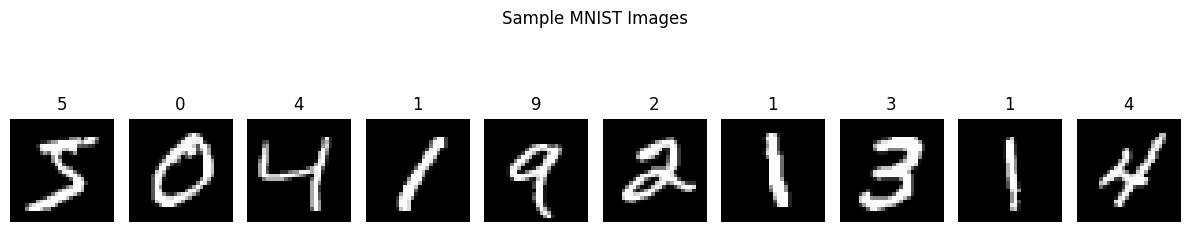

In [4]:
def show_mnist_samples(dataset, n_images=10):
    plt.figure(figsize=(12, 3))

    for i in range(n_images):
        image, label = dataset[i]
        plt.subplot(1, n_images, i + 1)
        plt.imshow(image.squeeze(), cmap="gray")
        plt.title(str(label))
        plt.axis("off")

    plt.suptitle("Sample MNIST Images")
    plt.tight_layout()
    plt.savefig("images/tutorial_03_mnist_samples.png", dpi=300, bbox_inches="tight")
    plt.show()


show_mnist_samples(train_full_dataset, n_images=10)


## 5. Define the Baseline ANN Model

The tutorial model has:

1. Flatten layer
2. Dense layer with 128 neurons and ReLU activation
3. Dense layer with 64 neurons and ReLU activation
4. Output layer with 10 neurons

PyTorch equivalent:

- `nn.Flatten()`
- `nn.Linear(784, 128)`
- `nn.ReLU()`
- `nn.Linear(128, 64)`
- `nn.ReLU()`
- `nn.Linear(64, 10)`

The final layer does not need `Softmax` because `CrossEntropyLoss` applies it internally.


In [5]:
class ANNModel(nn.Module):
    def __init__(self, hidden_layers=[128, 64], activation="relu", dropout_rate=0.0):
        super().__init__()

        activation_functions = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "sigmoid": nn.Sigmoid
        }

        if activation not in activation_functions:
            raise ValueError("activation must be 'relu', 'tanh', or 'sigmoid'")

        layers = []
        layers.append(nn.Flatten())

        input_size = 28 * 28

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(activation_functions[activation]())

            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))

            input_size = hidden_size

        layers.append(nn.Linear(input_size, 10))

        self.network = nn.Sequential(*layers)
        self.hidden_layers = hidden_layers
        self.activation = activation
        self.dropout_rate = dropout_rate

    def forward(self, x):
        return self.network(x)


baseline_model = ANNModel(
    hidden_layers=[128, 64],
    activation="relu",
    dropout_rate=0.0
).to(device)

print(baseline_model)


ANNModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 6. Model Summary and Trainable Parameters

In [6]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_parameter_table(model):
    rows = []

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            rows.append({
                "Layer": name,
                "Type": "Linear",
                "Input Features": module.in_features,
                "Output Features": module.out_features,
                "Parameters": module.weight.numel() + module.bias.numel()
            })

    return pd.DataFrame(rows)


baseline_param_table = model_parameter_table(baseline_model)
print("Total trainable parameters:", count_trainable_parameters(baseline_model))
baseline_param_table


Total trainable parameters: 109386


,Layer,Type,Input Features,Output Features,Parameters
0,network.1,Linear,784,128,100480
1,network.3,Linear,128,64,8256
2,network.5,Linear,64,10,650


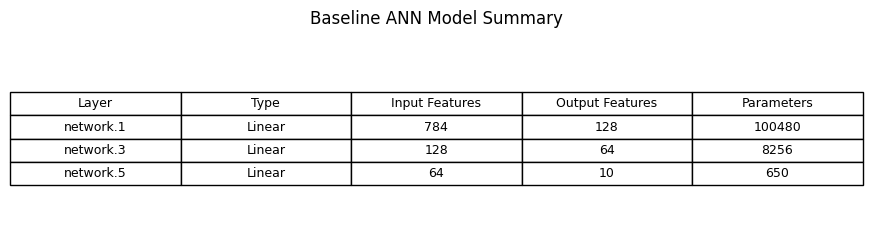

In [7]:
def save_dataframe_as_image(df, filename, title=None):
    fig_width = max(8, len(df.columns) * 2.2)
    fig_height = max(2.5, len(df) * 0.45 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


save_dataframe_as_image(
    baseline_param_table,
    "images/tutorial_03_baseline_model_summary.png",
    title="Baseline ANN Model Summary"
)


## 7. Training and Evaluation Functions

In [8]:
def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate_one_epoch(model, data_loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer_name="adam",
    learning_rate=0.001,
    epochs=10,
    weight_decay=0.0,
    early_stopping=False,
    patience=3,
    verbose=True
):
    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    elif optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9,
            weight_decay=weight_decay
        )
    elif optimizer_name.lower() == "rmsprop":
        optimizer = torch.optim.RMSprop(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    else:
        raise ValueError("optimizer_name must be 'adam', 'sgd', or 'rmsprop'")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "epoch_time": []
    }

    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_accuracy = evaluate_one_epoch(
            model,
            val_loader,
            criterion
        )

        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)
        history["epoch_time"].append(epoch_time)

        if verbose:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Train Acc: {train_accuracy * 100:.2f}% | "
                f"Val Acc: {val_accuracy * 100:.2f}%"
            )

        if early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping triggered at epoch {epoch + 1}")
                break

    total_time = time.time() - start_time

    if early_stopping:
        model.load_state_dict(best_model_state)

    return history, total_time


## 8. Train the Baseline Model

Baseline settings:

- Architecture: `[128, 64]`
- Activation: ReLU
- Optimizer: Adam
- Epochs: 10
- Batch size: 32


In [9]:
torch.manual_seed(SEED)

baseline_model = ANNModel(
    hidden_layers=[128, 64],
    activation="relu",
    dropout_rate=0.0
).to(device)

baseline_history, baseline_time = train_model(
    baseline_model,
    train_loader,
    val_loader,
    optimizer_name="adam",
    learning_rate=0.001,
    epochs=10,
    weight_decay=0.0,
    early_stopping=False,
    verbose=True
)

print("\nBaseline training time:", round(baseline_time, 2), "seconds")


Epoch 1/10 | Train Loss: 0.3153 | Val Loss: 0.1765 | Train Acc: 90.92% | Val Acc: 94.83%
Epoch 2/10 | Train Loss: 0.1354 | Val Loss: 0.1515 | Train Acc: 95.90% | Val Acc: 95.34%
Epoch 3/10 | Train Loss: 0.0922 | Val Loss: 0.1252 | Train Acc: 97.10% | Val Acc: 96.05%
Epoch 4/10 | Train Loss: 0.0683 | Val Loss: 0.0977 | Train Acc: 97.89% | Val Acc: 97.08%
Epoch 5/10 | Train Loss: 0.0519 | Val Loss: 0.1028 | Train Acc: 98.30% | Val Acc: 96.95%
Epoch 6/10 | Train Loss: 0.0411 | Val Loss: 0.0940 | Train Acc: 98.71% | Val Acc: 97.52%
Epoch 7/10 | Train Loss: 0.0332 | Val Loss: 0.0905 | Train Acc: 98.96% | Val Acc: 97.54%
Epoch 8/10 | Train Loss: 0.0290 | Val Loss: 0.1040 | Train Acc: 99.05% | Val Acc: 97.33%
Epoch 9/10 | Train Loss: 0.0239 | Val Loss: 0.0965 | Train Acc: 99.25% | Val Acc: 97.42%
Epoch 10/10 | Train Loss: 0.0212 | Val Loss: 0.1300 | Train Acc: 99.26% | Val Acc: 97.06%

Baseline training time: 176.82 seconds


## 9. Plot Training and Validation Accuracy/Loss

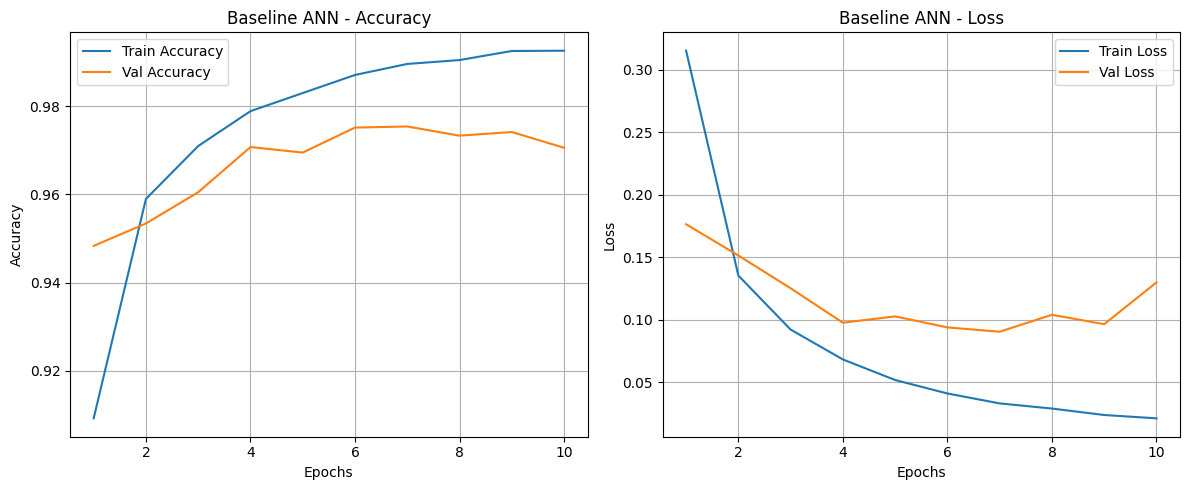

In [10]:
def plot_training_history(history, title, filename):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_training_history(
    baseline_history,
    "Baseline ANN",
    "images/tutorial_03_baseline_training_curves.png"
)


## 10. Evaluate the Baseline Model on Test Data

In [11]:
def get_predictions(model, data_loader):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_predictions)


y_true, y_pred = get_predictions(baseline_model, test_loader)

baseline_test_accuracy = accuracy_score(y_true, y_pred)

print("Baseline Test Accuracy:", round(baseline_test_accuracy * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Baseline Test Accuracy: 97.18 %

Confusion Matrix:
[[ 964    0    0    1    2    3    4    0    4    2]
 [   0 1109    5    2    0    1    2    2   14    0]
 [   2    0 1012    6    1    1    1    1    8    0]
 [   0    0    3  995    0    3    0    2    6    1]
 [   0    1    9    0  953    1    4    2    2   10]
 [   2    0    0   13    1  861    1    0   12    2]
 [   4    1    5    1    3    2  934    1    7    0]
 [   1    3    9   14    0    0    0  991    3    7]
 [   3    0    2    7    2    1    0    2  956    1]
 [   2    3    0   19    6    4    0   13   19  943]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       980
           1       0.99      0.98      0.98      1135
           2       0.97      0.98      0.97      1032
           3       0.94      0.99      0.96      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.97      0.97       892
           6   

## 11. Make Predictions and Visualize Results

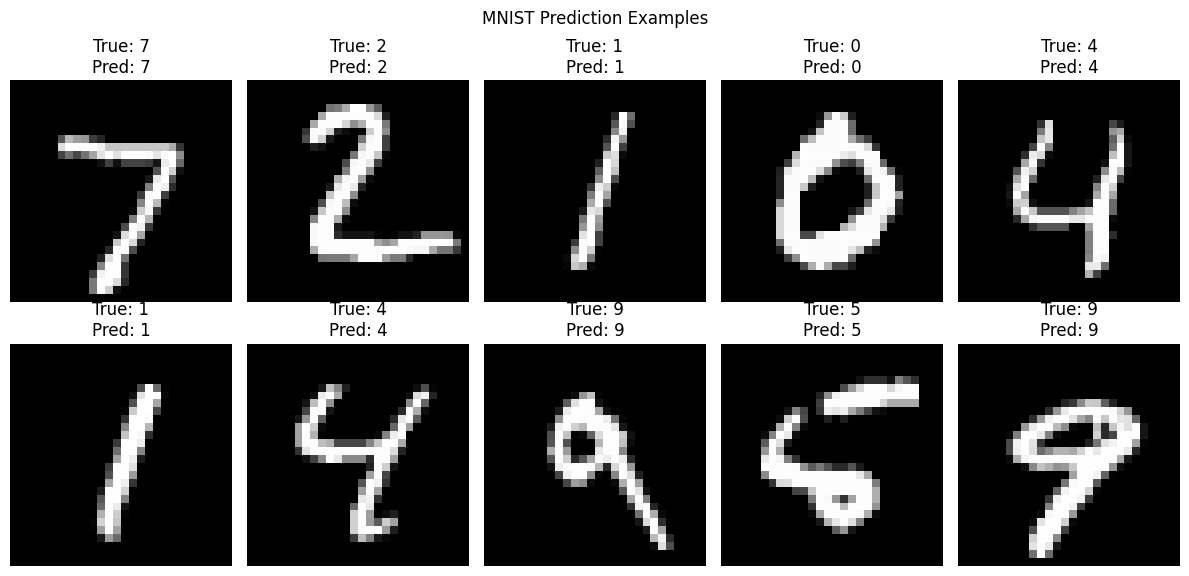

In [12]:
def visualize_predictions(model, dataset, n_images=10, filename="images/tutorial_03_prediction_examples.png"):
    model.eval()

    plt.figure(figsize=(12, 6))

    for i in range(n_images):
        image, true_label = dataset[i]
        image_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_input)
            _, predicted_label = torch.max(output, 1)

        plt.subplot(2, 5, i + 1)
        plt.imshow(image.squeeze(), cmap="gray")
        plt.title(f"True: {true_label}\nPred: {predicted_label.item()}")
        plt.axis("off")

    plt.suptitle("MNIST Prediction Examples")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


visualize_predictions(baseline_model, test_dataset)


# Task 1 — Experiment with Different Architectures and Activation Functions

The tutorial asks to modify the neural network architecture by:

- Adding more layers
- Changing the number of neurons
- Testing different activation functions such as ReLU, Tanh, and Sigmoid

The following configurations are tested:

1. Small ReLU model: `[64]`
2. Baseline ReLU model: `[128, 64]`
3. Deeper ReLU model: `[256, 128, 64]`
4. Tanh model: `[128, 64]`
5. Sigmoid model: `[128, 64]`


In [13]:
architecture_configs = [
    {"Name": "Small_ReLU", "Hidden Layers": [64], "Activation": "relu"},
    {"Name": "Baseline_ReLU", "Hidden Layers": [128, 64], "Activation": "relu"},
    {"Name": "Deep_ReLU", "Hidden Layers": [256, 128, 64], "Activation": "relu"},
    {"Name": "Tanh_Model", "Hidden Layers": [128, 64], "Activation": "tanh"},
    {"Name": "Sigmoid_Model", "Hidden Layers": [128, 64], "Activation": "sigmoid"},
]

architecture_results = []
architecture_histories = {}

for config in architecture_configs:
    print("\nTraining:", config["Name"])

    torch.manual_seed(SEED)

    model = ANNModel(
        hidden_layers=config["Hidden Layers"],
        activation=config["Activation"],
        dropout_rate=0.0
    ).to(device)

    history, training_time = train_model(
        model,
        train_loader,
        val_loader,
        optimizer_name="adam",
        learning_rate=0.001,
        epochs=5,
        weight_decay=0.0,
        early_stopping=False,
        verbose=False
    )

    y_true_arch, y_pred_arch = get_predictions(model, test_loader)
    test_accuracy = accuracy_score(y_true_arch, y_pred_arch)

    architecture_results.append({
        "Model": config["Name"],
        "Hidden Layers": str(config["Hidden Layers"]),
        "Activation": config["Activation"],
        "Final Train Accuracy": history["train_accuracy"][-1],
        "Final Val Accuracy": history["val_accuracy"][-1],
        "Final Train Loss": history["train_loss"][-1],
        "Final Val Loss": history["val_loss"][-1],
        "Test Accuracy": test_accuracy,
        "Training Time (s)": training_time
    })

    architecture_histories[config["Name"]] = history

architecture_results_df = pd.DataFrame(architecture_results)
architecture_results_df



Training: Small_ReLU

Training: Baseline_ReLU

Training: Deep_ReLU

Training: Tanh_Model

Training: Sigmoid_Model


,Model,Hidden Layers,Activation,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss,Test Accuracy,Training Time (s)
0,Small_ReLU,[64],relu,0.976500,0.964833,0.080338,0.118072,0.9674,81.217603
1,Baseline_ReLU,"[128, 64]",relu,0.983000,0.969500,0.051853,0.102759,0.9730,89.001900
2,Deep_ReLU,"[256, 128, 64]",relu,0.986187,0.974083,0.043833,0.090305,0.9773,91.680283
3,Tanh_Model,"[128, 64]",tanh,0.985292,0.968833,0.047862,0.101563,0.9711,88.931518
4,Sigmoid_Model,"[128, 64]",sigmoid,0.975229,0.963583,0.084054,0.116099,0.9668,83.699524


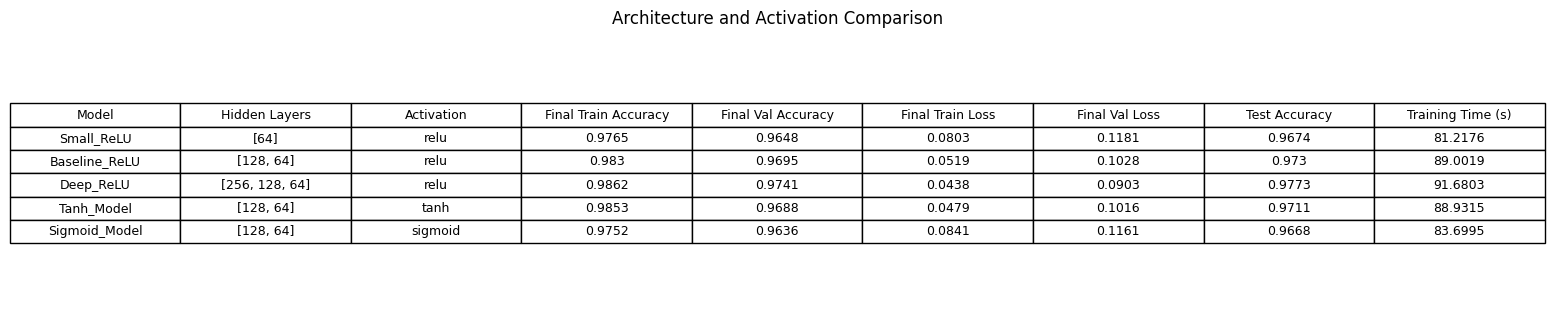

In [14]:
architecture_results_image_df = architecture_results_df.copy()

for column in [
    "Final Train Accuracy",
    "Final Val Accuracy",
    "Final Train Loss",
    "Final Val Loss",
    "Test Accuracy",
    "Training Time (s)"
]:
    architecture_results_image_df[column] = architecture_results_image_df[column].round(4)

save_dataframe_as_image(
    architecture_results_image_df,
    "images/tutorial_03_architecture_results_table.png",
    title="Architecture and Activation Comparison"
)


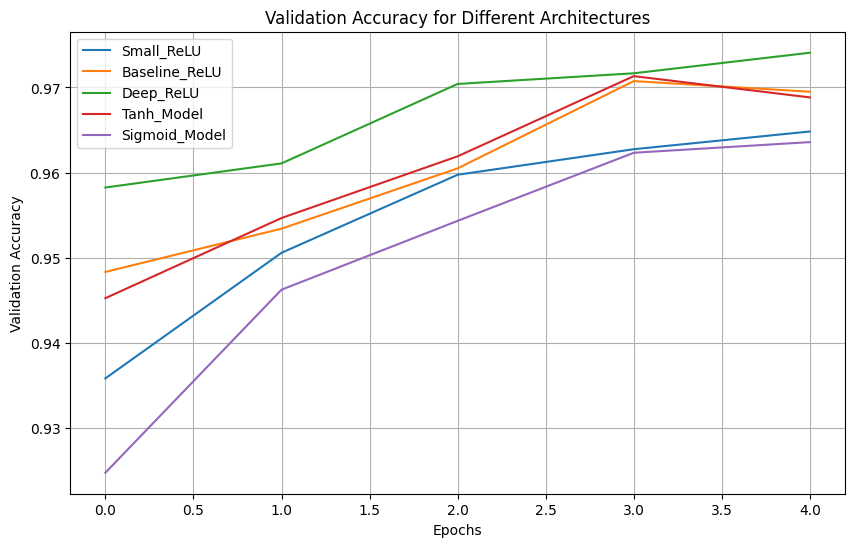

In [15]:
plt.figure(figsize=(10, 6))

for model_name, history in architecture_histories.items():
    plt.plot(history["val_accuracy"], label=model_name)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different Architectures")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_03_architecture_accuracy_curves.png", dpi=300, bbox_inches="tight")
plt.show()


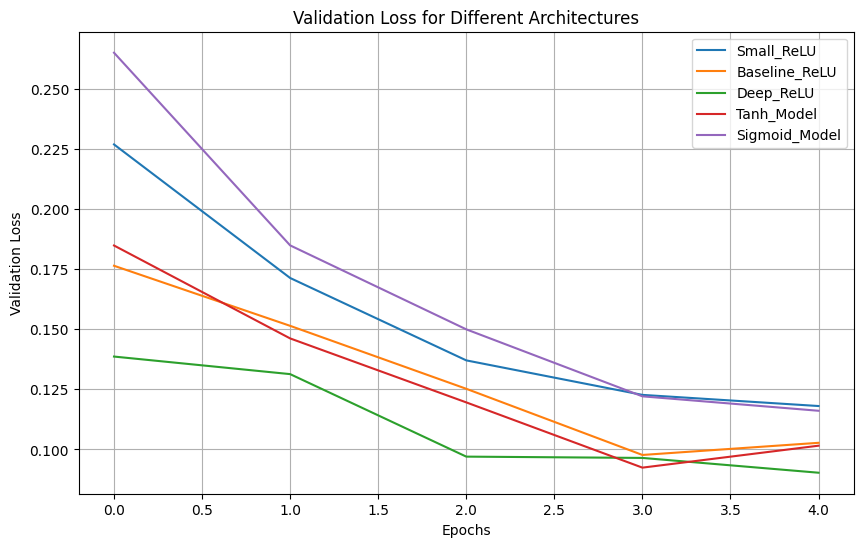

In [16]:
plt.figure(figsize=(10, 6))

for model_name, history in architecture_histories.items():
    plt.plot(history["val_loss"], label=model_name)

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Architectures")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_03_architecture_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()


# Task 2 — Compare Different Optimizers

The tutorial asks to compare different optimizers.

The tested optimizers are:

- SGD
- RMSprop
- Adam

The architecture is kept the same for a fair comparison:

- Hidden layers: `[128, 64]`
- Activation: ReLU
- Epochs: 5


In [17]:
optimizer_configs = [
    {"Name": "SGD", "Optimizer": "sgd", "Learning Rate": 0.01},
    {"Name": "RMSprop", "Optimizer": "rmsprop", "Learning Rate": 0.001},
    {"Name": "Adam", "Optimizer": "adam", "Learning Rate": 0.001},
]

optimizer_results = []
optimizer_histories = {}

for config in optimizer_configs:
    print("\nTraining with optimizer:", config["Name"])

    torch.manual_seed(SEED)

    model = ANNModel(
        hidden_layers=[128, 64],
        activation="relu",
        dropout_rate=0.0
    ).to(device)

    history, training_time = train_model(
        model,
        train_loader,
        val_loader,
        optimizer_name=config["Optimizer"],
        learning_rate=config["Learning Rate"],
        epochs=5,
        weight_decay=0.0,
        early_stopping=False,
        verbose=False
    )

    y_true_opt, y_pred_opt = get_predictions(model, test_loader)
    test_accuracy = accuracy_score(y_true_opt, y_pred_opt)

    optimizer_results.append({
        "Optimizer": config["Name"],
        "Learning Rate": config["Learning Rate"],
        "Final Train Accuracy": history["train_accuracy"][-1],
        "Final Val Accuracy": history["val_accuracy"][-1],
        "Final Train Loss": history["train_loss"][-1],
        "Final Val Loss": history["val_loss"][-1],
        "Test Accuracy": test_accuracy,
        "Training Time (s)": training_time
    })

    optimizer_histories[config["Name"]] = history

optimizer_results_df = pd.DataFrame(optimizer_results)
optimizer_results_df



Training with optimizer: SGD

Training with optimizer: RMSprop

Training with optimizer: Adam


,Optimizer,Learning Rate,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss,Test Accuracy,Training Time (s)
0,SGD,0.010,0.980479,0.966667,0.060979,0.110570,0.9695,83.192614
1,RMSprop,0.001,0.984542,0.970250,0.047925,0.111189,0.9750,84.450570
2,Adam,0.001,0.983000,0.969500,0.051853,0.102759,0.9730,87.168042


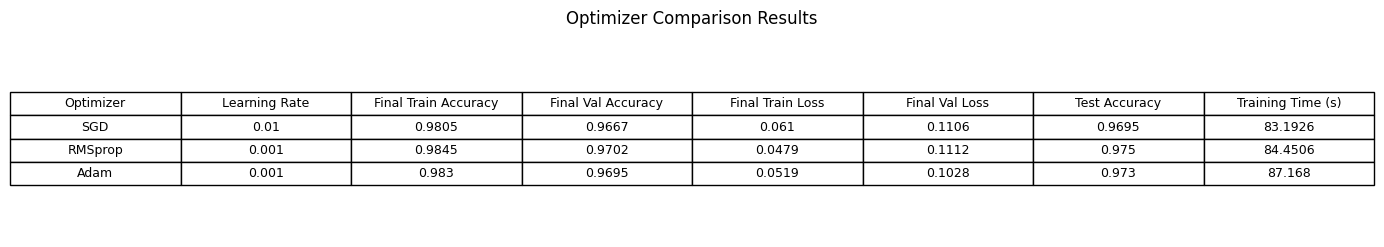

In [18]:
optimizer_results_image_df = optimizer_results_df.copy()

for column in [
    "Final Train Accuracy",
    "Final Val Accuracy",
    "Final Train Loss",
    "Final Val Loss",
    "Test Accuracy",
    "Training Time (s)"
]:
    optimizer_results_image_df[column] = optimizer_results_image_df[column].round(4)

save_dataframe_as_image(
    optimizer_results_image_df,
    "images/tutorial_03_optimizer_results_table.png",
    title="Optimizer Comparison Results"
)


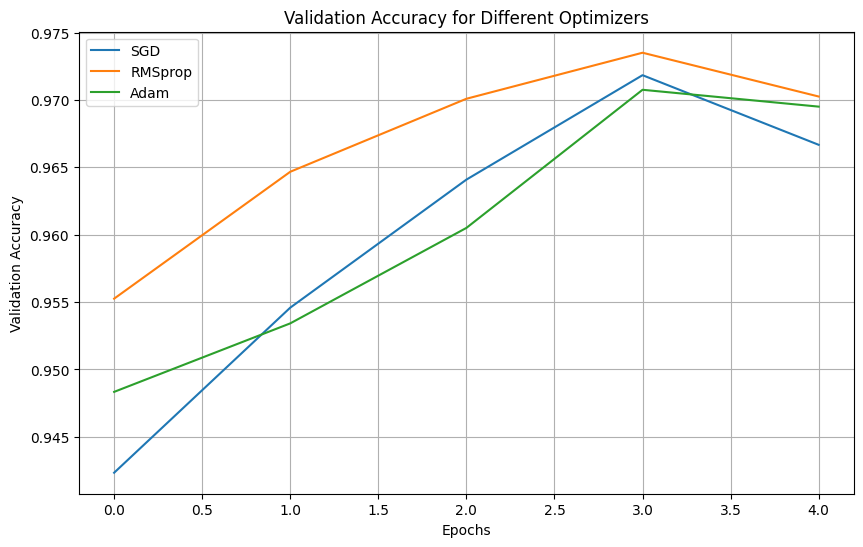

In [19]:
plt.figure(figsize=(10, 6))

for optimizer_name, history in optimizer_histories.items():
    plt.plot(history["val_accuracy"], label=optimizer_name)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different Optimizers")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_03_optimizer_accuracy_curves.png", dpi=300, bbox_inches="tight")
plt.show()


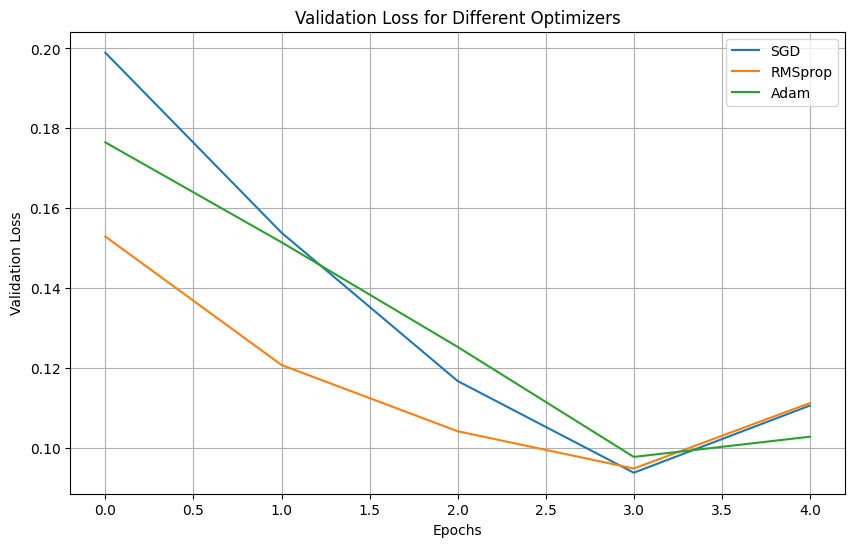

In [20]:
plt.figure(figsize=(10, 6))

for optimizer_name, history in optimizer_histories.items():
    plt.plot(history["val_loss"], label=optimizer_name)

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Optimizers")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_03_optimizer_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()


# Task 3 — Overfitting, Underfitting, and Number of Epochs

The tutorial asks to observe and interpret the training and validation accuracy/loss curves.

General interpretation:

- **Overfitting:** Training accuracy is much higher than validation accuracy, and validation loss increases or stagnates.
- **Underfitting:** Both training and validation accuracy are low, and training loss is high.
- **Well-fitted:** Training and validation curves are close, and both losses decrease smoothly.

To observe the effect of epoch count, the same baseline model is trained for more epochs.


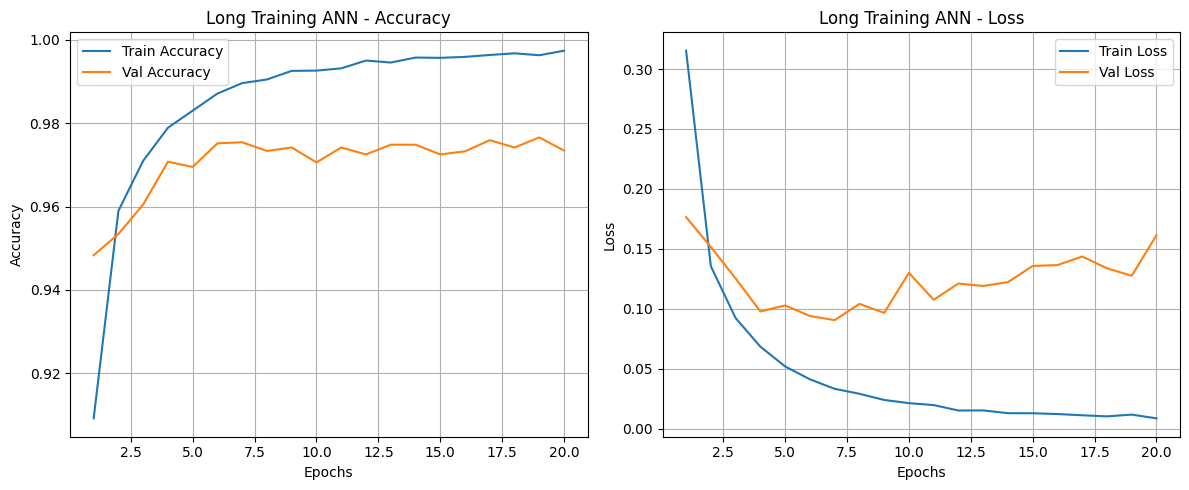

Long training time: 379.74 seconds


In [21]:
torch.manual_seed(SEED)

long_training_model = ANNModel(
    hidden_layers=[128, 64],
    activation="relu",
    dropout_rate=0.0
).to(device)

long_training_history, long_training_time = train_model(
    long_training_model,
    train_loader,
    val_loader,
    optimizer_name="adam",
    learning_rate=0.001,
    epochs=20,
    weight_decay=0.0,
    early_stopping=False,
    verbose=False
)

plot_training_history(
    long_training_history,
    "Long Training ANN",
    "images/tutorial_03_epoch_effect_curves.png"
)

print("Long training time:", round(long_training_time, 2), "seconds")


# Task 4 — Early Stopping

Early stopping stops training when validation loss no longer improves.

This helps reduce overfitting because the model does not continue training after validation performance stops improving.


Epoch 1/30 | Train Loss: 0.3153 | Val Loss: 0.1765 | Train Acc: 90.92% | Val Acc: 94.83%
Epoch 2/30 | Train Loss: 0.1354 | Val Loss: 0.1515 | Train Acc: 95.90% | Val Acc: 95.34%
Epoch 3/30 | Train Loss: 0.0922 | Val Loss: 0.1252 | Train Acc: 97.10% | Val Acc: 96.05%
Epoch 4/30 | Train Loss: 0.0683 | Val Loss: 0.0977 | Train Acc: 97.89% | Val Acc: 97.08%
Epoch 5/30 | Train Loss: 0.0519 | Val Loss: 0.1028 | Train Acc: 98.30% | Val Acc: 96.95%
Epoch 6/30 | Train Loss: 0.0411 | Val Loss: 0.0940 | Train Acc: 98.71% | Val Acc: 97.52%
Epoch 7/30 | Train Loss: 0.0332 | Val Loss: 0.0905 | Train Acc: 98.96% | Val Acc: 97.54%
Epoch 8/30 | Train Loss: 0.0290 | Val Loss: 0.1040 | Train Acc: 99.05% | Val Acc: 97.33%
Epoch 9/30 | Train Loss: 0.0239 | Val Loss: 0.0965 | Train Acc: 99.25% | Val Acc: 97.42%
Epoch 10/30 | Train Loss: 0.0212 | Val Loss: 0.1300 | Train Acc: 99.26% | Val Acc: 97.06%
Early stopping triggered at epoch 10


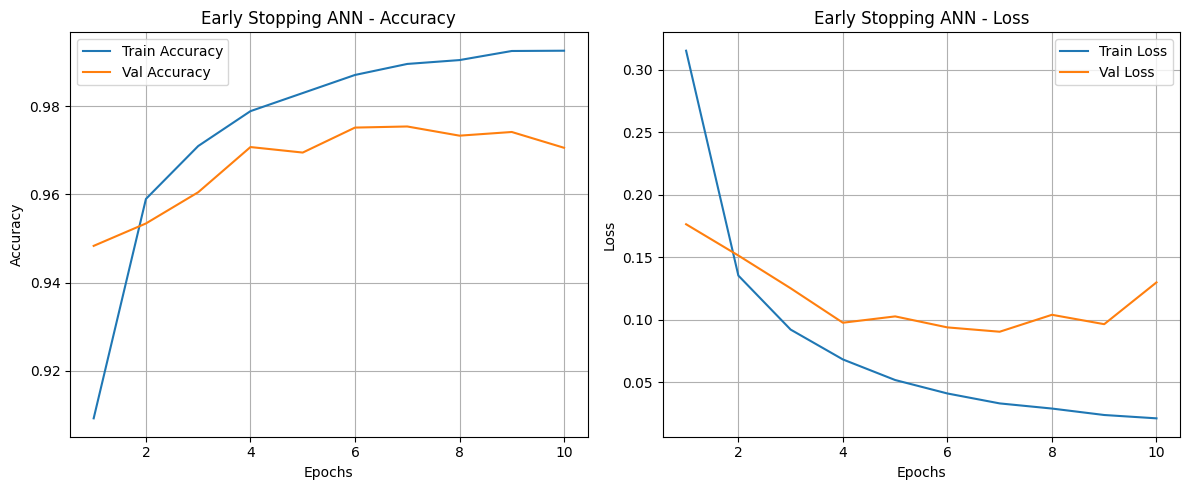

Early stopping training time: 208.91 seconds
Epochs actually trained: 10


In [22]:
torch.manual_seed(SEED)

early_stopping_model = ANNModel(
    hidden_layers=[128, 64],
    activation="relu",
    dropout_rate=0.0
).to(device)

early_stopping_history, early_stopping_time = train_model(
    early_stopping_model,
    train_loader,
    val_loader,
    optimizer_name="adam",
    learning_rate=0.001,
    epochs=30,
    weight_decay=0.0,
    early_stopping=True,
    patience=3,
    verbose=True
)

plot_training_history(
    early_stopping_history,
    "Early Stopping ANN",
    "images/tutorial_03_early_stopping_curves.png"
)

print("Early stopping training time:", round(early_stopping_time, 2), "seconds")
print("Epochs actually trained:", len(early_stopping_history["train_loss"]))


# Task 5 — Regularization Techniques

Regularization helps reduce overfitting.

In this notebook, the improved model uses:

- Dropout
- Weight decay

The goal is to keep training and validation curves close to each other.


Epoch 1/15 | Train Loss: 0.3712 | Val Loss: 0.1523 | Train Acc: 88.61% | Val Acc: 95.55%
Epoch 2/15 | Train Loss: 0.1625 | Val Loss: 0.1159 | Train Acc: 95.25% | Val Acc: 96.62%
Epoch 3/15 | Train Loss: 0.1241 | Val Loss: 0.1191 | Train Acc: 96.36% | Val Acc: 96.54%
Epoch 4/15 | Train Loss: 0.1034 | Val Loss: 0.1041 | Train Acc: 96.86% | Val Acc: 96.88%
Epoch 5/15 | Train Loss: 0.0917 | Val Loss: 0.0870 | Train Acc: 97.30% | Val Acc: 97.39%
Epoch 6/15 | Train Loss: 0.0860 | Val Loss: 0.0934 | Train Acc: 97.40% | Val Acc: 97.15%
Epoch 7/15 | Train Loss: 0.0802 | Val Loss: 0.0977 | Train Acc: 97.62% | Val Acc: 97.32%
Epoch 8/15 | Train Loss: 0.0760 | Val Loss: 0.0903 | Train Acc: 97.70% | Val Acc: 97.62%
Early stopping triggered at epoch 8


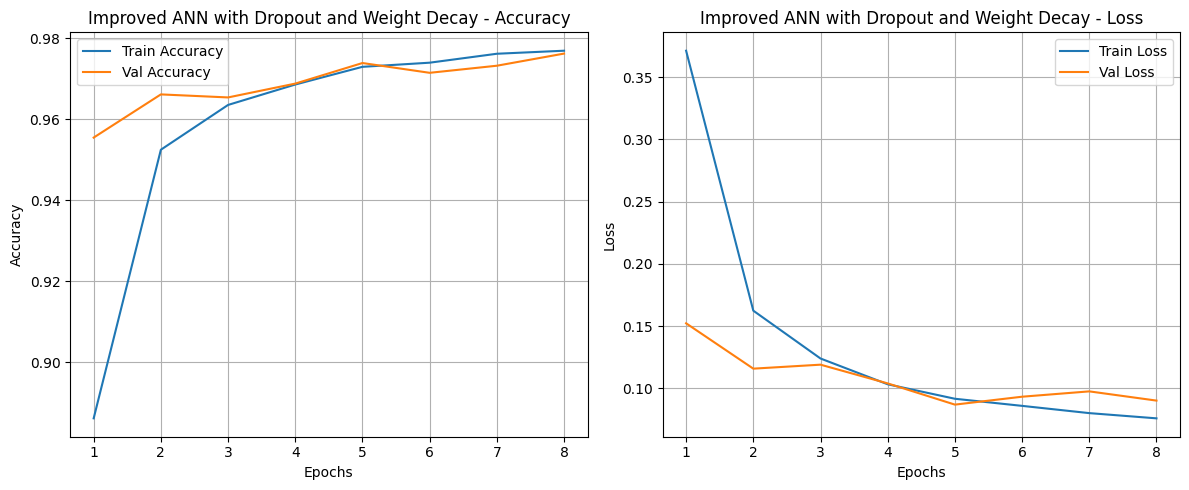

Improved Model Test Accuracy: 97.61 %
Improved training time: 183.85 seconds


In [23]:
torch.manual_seed(SEED)

improved_model = ANNModel(
    hidden_layers=[256, 128, 64],
    activation="relu",
    dropout_rate=0.2
).to(device)

improved_history, improved_time = train_model(
    improved_model,
    train_loader,
    val_loader,
    optimizer_name="adam",
    learning_rate=0.001,
    epochs=15,
    weight_decay=1e-4,
    early_stopping=True,
    patience=3,
    verbose=True
)

plot_training_history(
    improved_history,
    "Improved ANN with Dropout and Weight Decay",
    "images/tutorial_03_improved_model_curves.png"
)

y_true_improved, y_pred_improved = get_predictions(improved_model, test_loader)
improved_test_accuracy = accuracy_score(y_true_improved, y_pred_improved)

print("Improved Model Test Accuracy:", round(improved_test_accuracy * 100, 2), "%")
print("Improved training time:", round(improved_time, 2), "seconds")


## 12. Compare Baseline and Improved Model

In [24]:
comparison_df = pd.DataFrame([
    {
        "Model": "Baseline ANN",
        "Hidden Layers": "[128, 64]",
        "Regularization": "None",
        "Final Train Accuracy": baseline_history["train_accuracy"][-1],
        "Final Val Accuracy": baseline_history["val_accuracy"][-1],
        "Test Accuracy": baseline_test_accuracy,
        "Epochs Trained": len(baseline_history["train_loss"])
    },
    {
        "Model": "Improved ANN",
        "Hidden Layers": "[256, 128, 64]",
        "Regularization": "Dropout + Weight Decay + Early Stopping",
        "Final Train Accuracy": improved_history["train_accuracy"][-1],
        "Final Val Accuracy": improved_history["val_accuracy"][-1],
        "Test Accuracy": improved_test_accuracy,
        "Epochs Trained": len(improved_history["train_loss"])
    }
])

comparison_image_df = comparison_df.copy()

for column in ["Final Train Accuracy", "Final Val Accuracy", "Test Accuracy"]:
    comparison_image_df[column] = comparison_image_df[column].round(4)

comparison_df


,Model,Hidden Layers,Regularization,Final Train Accuracy,Final Val Accuracy,Test Accuracy,Epochs Trained
0,Baseline ANN,"[128, 64]",None,0.992604,0.970583,0.9718,10
1,Improved ANN,"[256, 128, 64]",Dropout + Weight Decay + Early Stopping,0.976958,0.976250,0.9761,8


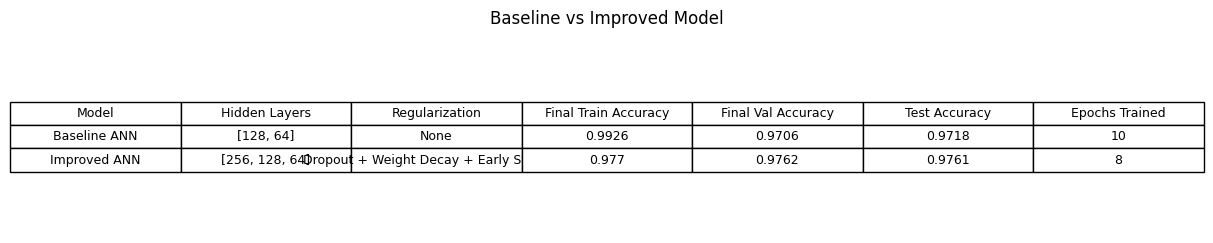

In [25]:
save_dataframe_as_image(
    comparison_image_df,
    "images/tutorial_03_baseline_vs_improved_table.png",
    title="Baseline vs Improved Model"
)


# Final Observations

## Baseline Model

The baseline ANN used two hidden layers with ReLU activation.  
The training and validation curves help determine whether the model is underfitting, overfitting, or well-fitted.

## Architecture Experiments

Different architectures and activation functions were tested.  
ReLU usually performs well because it avoids the vanishing-gradient issue that can occur with sigmoid activation in hidden layers.

## Optimizer Comparison

SGD, RMSprop, and Adam were compared.  
Adam usually converges quickly because it adapts the learning rate during training.

## Early Stopping and Regularization

Early stopping prevents unnecessary training after validation loss stops improving.  
Dropout and weight decay help reduce overfitting by limiting how strongly the model depends on specific neurons or large weights.

## Key Learning

This tutorial shows that training a neural network is not only about increasing accuracy.  
The training and validation curves are important for understanding whether the model generalizes well to unseen data.
